# Inverse Transform Algorithm for Simulation & Numerical Methods

This notebook demonstrates the **Inverse Transform Sampling** method, a fundamental technique in Monte Carlo simulation for generating random samples from arbitrary probability distributions.

## Overview
The inverse transform algorithm allows us to generate random variates from any distribution for which we can compute the inverse of its cumulative distribution function (CDF).


## Mathematical Foundation

Given a random variable $X$ with CDF $F_X(x) = P(X \leq x)$, if $F_X$ is strictly increasing and continuous, then:

$$U = F_X(X) \sim \text{Uniform}(0, 1)$$

Conversely, if $U \sim \text{Uniform}(0, 1)$, then:

$$X = F_X^{-1}(U)$$

has the desired distribution.

### Algorithm Steps:
1. Generate $U \sim \text{Uniform}(0, 1)$
2. Compute $X = F^{-1}(U)$
3. Return $X$
4. 

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Global style settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


## Example 1: Exponential Distribution

The exponential distribution with rate parameter $\lambda > 0$ has:

- **PDF:** $f(x) = \lambda e^{-\lambda x}, \quad x \geq 0$
- **CDF:** $F(x) = 1 - e^{-\lambda x}$
- **Inverse CDF:** $F^{-1}(u) = -\frac{1}{\lambda}\ln(1-u) = -\frac{1}{\lambda}\ln(u)$

*(The last equality holds because $1-U$ and $U$ are both uniform on $(0,1)$.)*


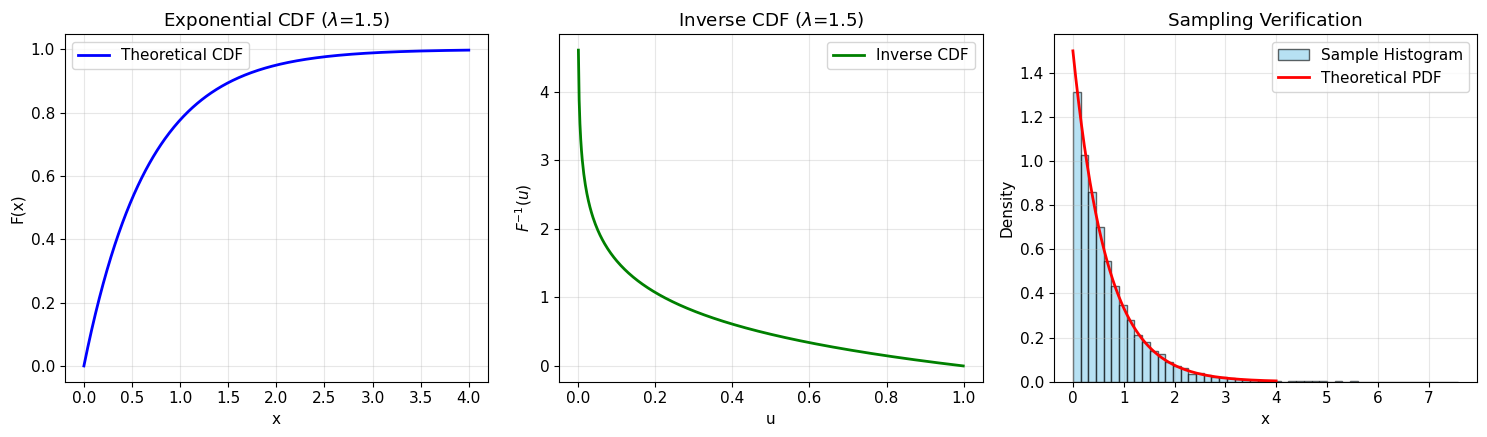

Sample mean: 0.6761 (Theoretical: 0.6667)
Sample std:  0.6705 (Theoretical: 0.6667)


In [15]:
# Parameters
lam = 1.5  # rate parameter

# Inverse CDF (Quantile function) for Exponential
def inv_cdf_exponential(u, rate):
    return -np.log(u) / rate

# Theoretical PDF
def pdf_exponential(x, rate):
    return rate * np.exp(-rate * x)

# Theoretical CDF
def cdf_exponential(x, rate):
    return 1 - np.exp(-rate * x)

# Generate uniform samples
u_samples = np.random.rand(10_000)

# Transform to exponential samples
x_samples = inv_cdf_exponential(u_samples, lam)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Plot 1: CDF
x_grid = np.linspace(0, 4, 500)
axes[0].plot(x_grid, cdf_exponential(x_grid, lam), 'b-', lw=2, label='Theoretical CDF')
axes[0].set_title(rf'Exponential CDF ($\lambda$={lam})')
axes[0].set_xlabel('x')
axes[0].set_ylabel('F(x)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Inverse CDF
u_grid = np.linspace(0.001, 0.999, 500)
axes[1].plot(u_grid, inv_cdf_exponential(u_grid, lam), 'g-', lw=2, label='Inverse CDF')
axes[1].set_title(rf'Inverse CDF ($\lambda$={lam})')
axes[1].set_xlabel('u')
axes[1].set_ylabel(rf'$F^{{-1}}(u)$')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Histogram vs PDF
axes[2].hist(x_samples, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Sample Histogram')
axes[2].plot(x_grid, pdf_exponential(x_grid, lam), 'r-', lw=2, label='Theoretical PDF')
axes[2].set_title('Sampling Verification')
axes[2].set_xlabel('x')
axes[2].set_ylabel('Density')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Sample mean: {np.mean(x_samples):.4f} (Theoretical: {1/lam:.4f})")
print(f"Sample std:  {np.std(x_samples):.4f} (Theoretical: {1/lam:.4f})")


## Example 2: Custom Continuous Distribution

Consider a distribution with PDF $f(x) = 2x$ on $[0, 1]$.

- **CDF:** $F(x) = x^2$
- **Inverse CDF:** $F^{-1}(u) = \sqrt{u}$

This demonstrates how inverse transform works for non-standard distributions.


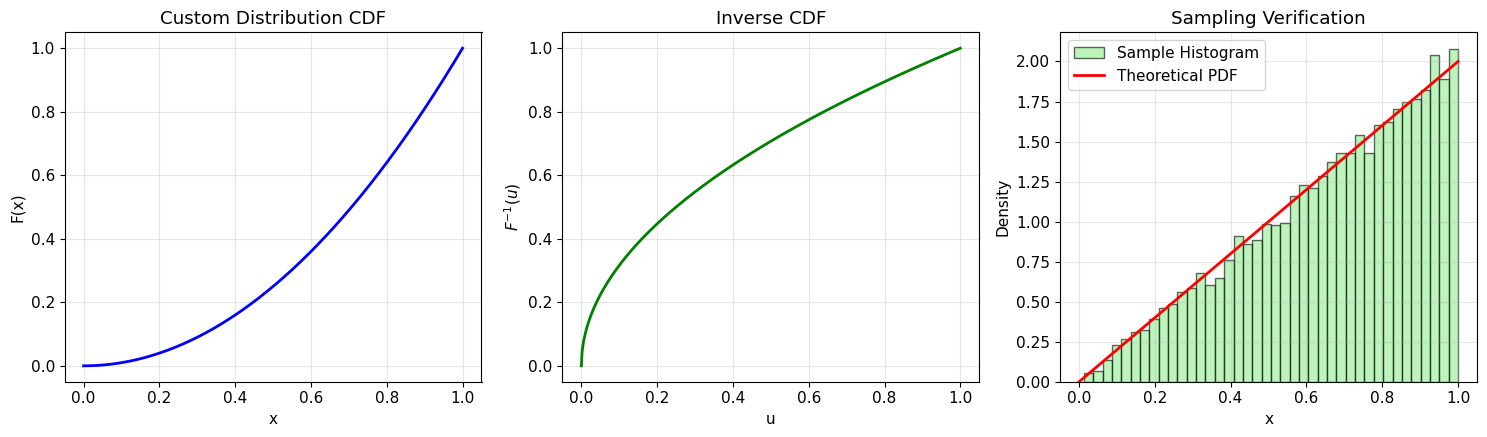

Area under PDF (numerical): 1.000000


In [16]:
# Custom distribution: f(x) = 2x on [0,1]

def inv_cdf_custom(u):
    return np.sqrt(u)

def pdf_custom(x):
    return 2 * x

def cdf_custom(x):
    return x**2

# Generate samples
u_samples_custom = np.random.rand(10_000)
x_samples_custom = inv_cdf_custom(u_samples_custom)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

x_grid_custom = np.linspace(0, 1, 500)

# Plot 1: CDF
axes[0].plot(x_grid_custom, cdf_custom(x_grid_custom), 'b-', lw=2)
axes[0].set_title('Custom Distribution CDF')
axes[0].set_xlabel('x')
axes[0].set_ylabel('F(x)')
axes[0].grid(True, alpha=0.3)

# Plot 2: Inverse CDF
u_grid_custom = np.linspace(0, 1, 500)
axes[1].plot(u_grid_custom, inv_cdf_custom(u_grid_custom), 'g-', lw=2)
axes[1].set_title('Inverse CDF')
axes[1].set_xlabel('u')
axes[1].set_ylabel(r'$F^{-1}(u)$')
axes[1].grid(True, alpha=0.3)

# Plot 3: Histogram vs PDF
axes[2].hist(x_samples_custom, bins=40, density=True, alpha=0.6, color='lightgreen', edgecolor='black', label='Sample Histogram')
axes[2].plot(x_grid_custom, pdf_custom(x_grid_custom), 'r-', lw=2, label='Theoretical PDF')
axes[2].set_title('Sampling Verification')
axes[2].set_xlabel('x')
axes[2].set_ylabel('Density')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Numerical verification: area under PDF should be 1
area_pdf = np.trapezoid(pdf_custom(x_grid_custom), x_grid_custom)
print(f"Area under PDF (numerical): {area_pdf:.6f}")


## Geometric Interpretation

The inverse transform method has a simple geometric meaning: we generate a uniform height $u$ on the CDF axis and project horizontally to the curve $u = F(x)$, then vertically down to the $x$-axis.


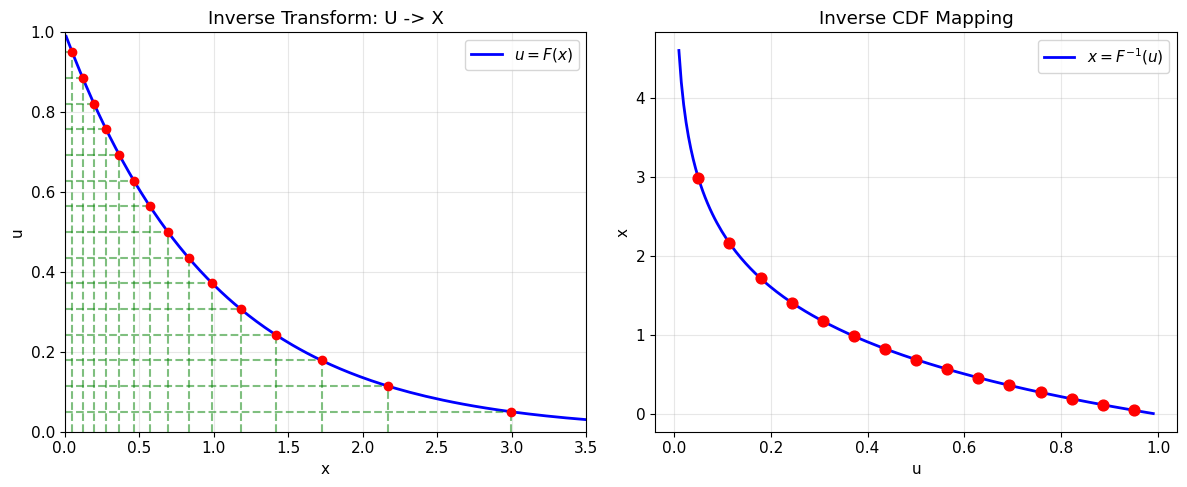

In [17]:
# Geometric interpretation: mapping from U to X
lam = 1.0
n_arrows = 15

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Uniform samples on y-axis, mapped to x-axis via inverse CDF
u_vals = np.linspace(0.05, 0.95, n_arrows)
x_vals = -np.log(u_vals) / lam

# Plot inverse CDF
u_fine = np.linspace(0.01, 0.99, 200)
x_fine = -np.log(u_fine) / lam
axes[0].plot(x_fine, u_fine, 'b-', lw=2, label=r'$u = F(x)$')
axes[0].scatter(x_vals, u_vals, color='red', zorder=5)
for x, u in zip(x_vals, u_vals):
    axes[0].plot([0, x], [u, u], 'g--', alpha=0.5)
    axes[0].plot([x, x], [0, u], 'g--', alpha=0.5)
axes[0].set_xlim(0, 3.5)
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('x')
axes[0].set_ylabel('u')
axes[0].set_title('Inverse Transform: U -> X')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Scatter showing U vs X
axes[1].scatter(u_vals, x_vals, color='red', s=60, zorder=5)
axes[1].plot(u_fine, x_fine, 'b-', lw=2, label=r'$x = F^{-1}(u)$')
axes[1].set_xlabel('u')
axes[1].set_ylabel('x')
axes[1].set_title('Inverse CDF Mapping')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Example 3: Discrete Distribution

The inverse transform method also applies to discrete distributions. Consider a random variable $X$ with:

$$P(X = x_i) = p_i, \quad i = 1, 2, \dots, n$$

The CDF is a step function: $F(x) = \sum_{x_i \leq x} p_i$

**Algorithm:**
1. Generate $U \sim \text{Uniform}(0,1)$
2. Find the smallest $i$ such that $F(x_i) \geq U$
3. Return $x_i$

This is essentially a table lookup method.


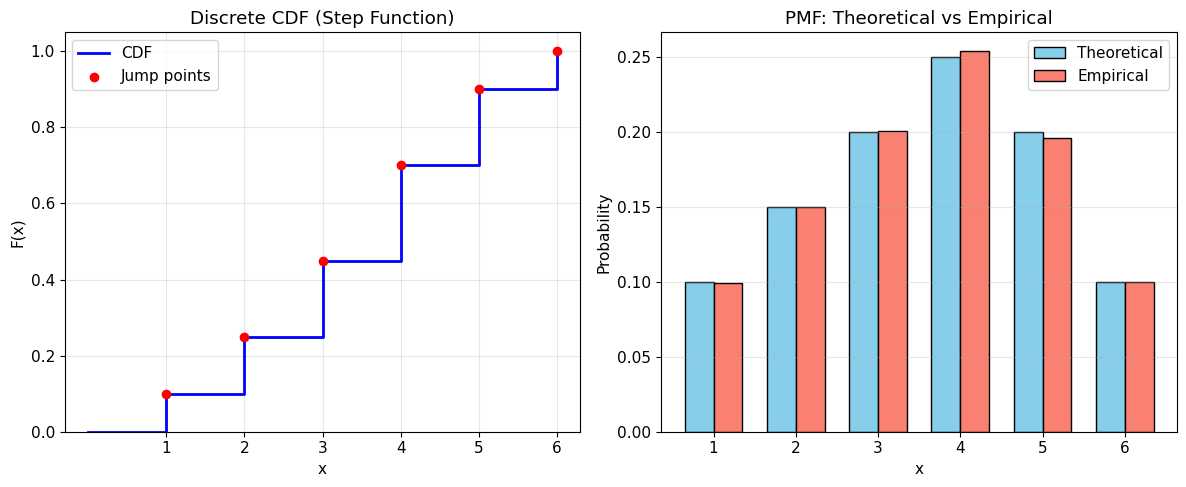

Value | Theoretical | Empirical
------------------------------
  1   |   0.1000    |  0.0995
  2   |   0.1500    |  0.1501
  3   |   0.2000    |  0.2006
  4   |   0.2500    |  0.2538
  5   |   0.2000    |  0.1958
  6   |   0.1000    |  0.1001


In [18]:
# Discrete distribution example
values = np.array([1, 2, 3, 4, 5, 6])
probs = np.array([0.10, 0.15, 0.20, 0.25, 0.20, 0.10])

# Verify probabilities sum to 1
assert np.isclose(np.sum(probs), 1.0), "Probabilities must sum to 1"

# Compute CDF
cdf_discrete = np.cumsum(probs)

def sample_discrete(u, vals, cdf):
    """Vectorized inverse transform for discrete distribution."""
    # For each u, find the first index where cdf >= u
    indices = np.searchsorted(cdf, u, side='left')
    return vals[indices]

# Generate samples
n_samples = 20_000
u_discrete = np.random.rand(n_samples)
samples_discrete = sample_discrete(u_discrete, values, cdf_discrete)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: CDF Step Function
axes[0].step(np.concatenate([[0], values]), np.concatenate([[0], cdf_discrete]), 
             where='post', lw=2, color='blue', label='CDF')
axes[0].scatter(values, cdf_discrete, color='red', zorder=5, label='Jump points')
axes[0].set_title('Discrete CDF (Step Function)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('F(x)')
axes[0].set_xticks(values)
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Empirical vs Theoretical PMF
empirical_probs = np.bincount(samples_discrete.astype(int), minlength=7)[1:] / n_samples
width = 0.35
x_pos = np.arange(len(values))

axes[1].bar(x_pos - width/2, probs, width, label='Theoretical', color='skyblue', edgecolor='black')
axes[1].bar(x_pos + width/2, empirical_probs, width, label='Empirical', color='salmon', edgecolor='black')
axes[1].set_title('PMF: Theoretical vs Empirical')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Probability')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(values)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print comparison table
print("Value | Theoretical | Empirical")
print("-" * 30)
for v, p, e in zip(values, probs, empirical_probs):
    print(f"  {v}   |   {p:.4f}    |  {e:.4f}")


## Numerical Inversion (When Closed Form is Unavailable)

When $F^{-1}$ has no closed form, we can numerically solve $F(x) = u$ for each $u$ using root-finding methods like bisection.

**Example:** The standard normal CDF $\Phi(x)$ has no elementary closed-form inverse. We demonstrate numerical inversion using bisection.


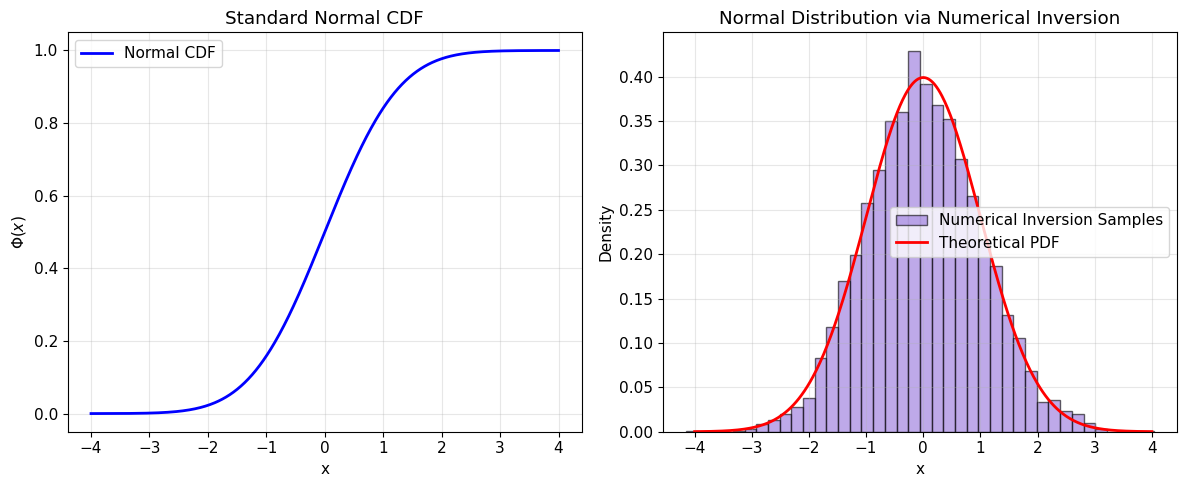

Sample mean: 0.0028 (Theoretical: 0.0000)
Sample std:  1.0032 (Theoretical: 1.0000)


In [19]:
import math

def normal_cdf(x, mu=0, sigma=1):
    return 0.5 * (1 + math.erf((x - mu) / (sigma * np.sqrt(2))))

def normal_pdf(x, mu=0, sigma=1):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)

# Numerical inversion via bisection
def inv_cdf_normal_bisection(u, mu=0, sigma=1, x_min=-6, x_max=6, tol=1e-12):
    u = np.atleast_1d(u)
    results = np.empty(len(u))
    for i, val in enumerate(u):
        a, b = x_min, x_max
        for _ in range(60):
            c = (a + b) / 2
            fc = normal_cdf(c, mu, sigma)
            if abs(fc - val) < tol or (b - a) < tol:
                results[i] = c
                break
            if fc < val:
                a = c
            else:
                b = c
        else:
            results[i] = c
    return results

# Generate normal samples via numerical inversion
n_normal = 5000
u_normal = np.random.rand(n_normal)
x_normal = inv_cdf_normal_bisection(u_normal)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_grid_norm = np.linspace(-4, 4, 500)
pdf_norm = normal_pdf(x_grid_norm)

axes[0].plot(x_grid_norm, [normal_cdf(x) for x in x_grid_norm], 'b-', lw=2, label='Normal CDF')
axes[0].set_title('Standard Normal CDF')
axes[0].set_xlabel('x')
axes[0].set_ylabel(r'$\Phi(x)$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(x_normal, bins=40, density=True, alpha=0.6, color='mediumpurple', 
             edgecolor='black', label='Numerical Inversion Samples')
axes[1].plot(x_grid_norm, pdf_norm, 'r-', lw=2, label='Theoretical PDF')
axes[1].set_title('Normal Distribution via Numerical Inversion')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Sample mean: {np.mean(x_normal):.4f} (Theoretical: 0.0000)")
print(f"Sample std:  {np.std(x_normal):.4f} (Theoretical: 1.0000)")


## Convergence Analysis

As the sample size increases, the empirical distribution converges to the theoretical distribution (Glivenko-Cantelli theorem). Let's visualize this convergence for the exponential distribution.


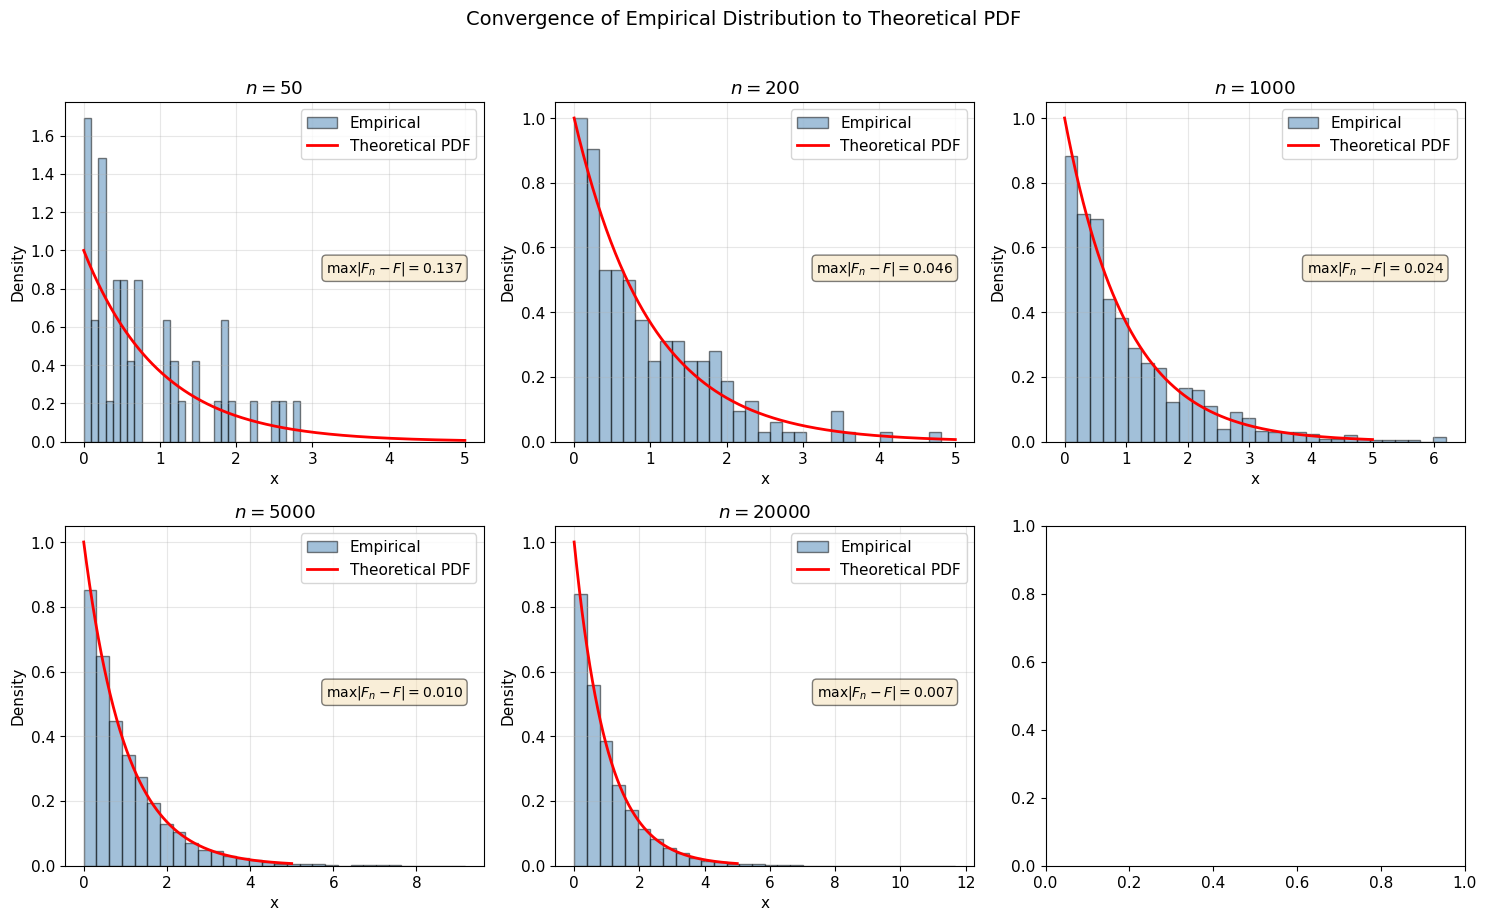

In [20]:
# Convergence analysis for exponential distribution
sample_sizes = [50, 200, 1000, 5000, 20000]
lam = 1.0

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

x_grid_conv = np.linspace(0, 5, 500)
pdf_theory = lam * np.exp(-lam * x_grid_conv)

for idx, n in enumerate(sample_sizes):
    u = np.random.rand(n)
    samples = -np.log(u) / lam
    
    # Plot histogram
    axes[idx].hist(samples, bins=30, density=True, alpha=0.5, color='steelblue', 
                   edgecolor='black', label='Empirical')
    axes[idx].plot(x_grid_conv, pdf_theory, 'r-', lw=2, label='Theoretical PDF')
    axes[idx].set_title(rf'$n = {n}$')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    
    # Compute max absolute difference between empirical and theoretical CDF
    sorted_samples = np.sort(samples)
    empirical_cdf = np.arange(1, n+1) / n
    theoretical_cdf = 1 - np.exp(-lam * sorted_samples)
    ks_stat = np.max(np.abs(empirical_cdf - theoretical_cdf))
    axes[idx].text(0.95, 0.5, rf'$\max|F_n-F|={ks_stat:.3f}$', 
                   transform=axes[idx].transAxes, ha='right', fontsize=10,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Convergence of Empirical Distribution to Theoretical PDF', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Limitations and Practical Considerations

1. **Invertibility:** The CDF must be invertible (or at least a generalized inverse must exist).
2. **Computational Cost:** For complex distributions, computing $F^{-1}$ may be expensive.
3. **Multivariate Extensions:** The basic inverse transform does not easily generalize to multiple dimensions (copulas are one extension).
4. **Alternative Methods:** When $F^{-1}$ is not available in closed form, methods like **Acceptance-Rejection**, **Box-Muller**, or numerical root-finding for $F(x) = u$ are used.

## Summary

The Inverse Transform Algorithm is elegant and exact:
- Transform uniform random numbers via the inverse CDF
- Works for continuous and discrete distributions
- Provides a direct bridge between uniform randomness and arbitrary distributions